# Analise de Crimes Contra Vulneraveis no Brasil
## Analise Exploratoria Inicial (EDA)

**Equipe:** Sanderson Machado, Pedro Abreu, Arthur Cavalcante  
**Fonte:** SINESP — Sistema Nacional de Informacoes de Seguranca Publica  
**Periodo:** 2016-2025 | 2026 excluido (ano parcial: Jan-Mar apenas)  
**Granularidade:** Anual por Unidade Federativa (UF)

---

**Objetivo:** Explorar a distribuicao temporal e geografica dos crimes do SINESP,
identificar inconsistencias de subnotificacao, e preparar a base para correlacao com IBGE.

> **Nota:** `sequestro` e `exploracao_infantil` nao estao no SINESP.
> A secao de correlacao socieconomica aguarda os dados do IBGE.

---
## 1. Importacoes e Configuracao

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

DATA_DIR      = Path('../data/processed')
SINESP_FILE   = DATA_DIR / 'sinesp_crimes.csv'
ANO_INICIO    = 2018   # 2016-2017 excluidos: subnotificacao sistematica
ANO_FIM       = 2025   # 2026 excluido: ano parcial (Jan-Mar)
VAR_PRINCIPAL = 'estupro_vulneravel'

print(f'Janela de analise: {ANO_INICIO} a {ANO_FIM}')

Janela de analise: 2018 a 2025


---
## 2. Carregamento dos Dados

In [12]:
df_raw = pd.read_csv(SINESP_FILE)
df_raw['ano'] = df_raw['ano'].astype(int)
df_raw['uf']  = df_raw['uf'].astype(str)

print(f'Shape: {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas')
print(f'Colunas: {list(df_raw.columns)}')
print(f'Anos: {sorted(df_raw["ano"].unique())}')
print(f'UFs ({df_raw["uf"].nunique()}): {sorted(df_raw["uf"].unique())}')
df_raw.head(10)
#df_raw[df_raw['uf'] == 'SP']


Shape: 297 linhas x 4 colunas
Colunas: ['uf', 'ano', 'estupro', 'estupro_vulneravel']
Anos: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
UFs (27): ['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']


,uf,ano,estupro,estupro_vulneravel
0,AC,2016,0,0
1,AC,2017,0,0
2,AC,2018,83,213
3,AC,2019,139,238
4,AC,2020,102,300
5,AC,2021,145,489
6,AC,2022,297,443
7,AC,2023,282,459
8,AC,2024,210,560
9,AC,2025,123,482


---
## 3. Inspecao Inicial

In [13]:
print('=== Tipos de dados ===')
print(df_raw.dtypes)
print()
df_raw.info()

=== Tipos de dados ===
uf                      str
ano                   int64
estupro               int64
estupro_vulneravel    int64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   uf                  297 non-null    str  
 1   ano                 297 non-null    int64
 2   estupro             297 non-null    int64
 3   estupro_vulneravel  297 non-null    int64
dtypes: int64(3), str(1)
memory usage: 9.4 KB


In [14]:
dupl = df_raw.duplicated(subset=['uf', 'ano']).sum()
combos_reais     = len(df_raw)
combos_esperados = 27 * df_raw['ano'].nunique()
print(f'Duplicatas (uf+ano): {dupl}')
print(f'Combinacoes esperadas: {combos_esperados} | presentes: {combos_reais}')

Duplicatas (uf+ano): 0
Combinacoes esperadas: 297 | presentes: 297


---
## 4. Qualidade dos Dados

Tres dimensoes verificadas:
1. **Valores nulos** - ausencia de dados
2. **Cobertura temporal** - quais UFs reportaram em cada ano
3. **Zeros sistematicos** - UFs com zero (falha de notificacao vs ausencia real)

In [15]:
nulos = df_raw.isnull().sum()
print('Nulos por coluna:')
print(nulos)
print(f'\nTotal: {nulos.sum()} ({nulos.sum()/df_raw.size*100:.1f}% das celulas)')

Nulos por coluna:
uf                    0
ano                   0
estupro               0
estupro_vulneravel    0
dtype: int64

Total: 0 (0.0% das celulas)


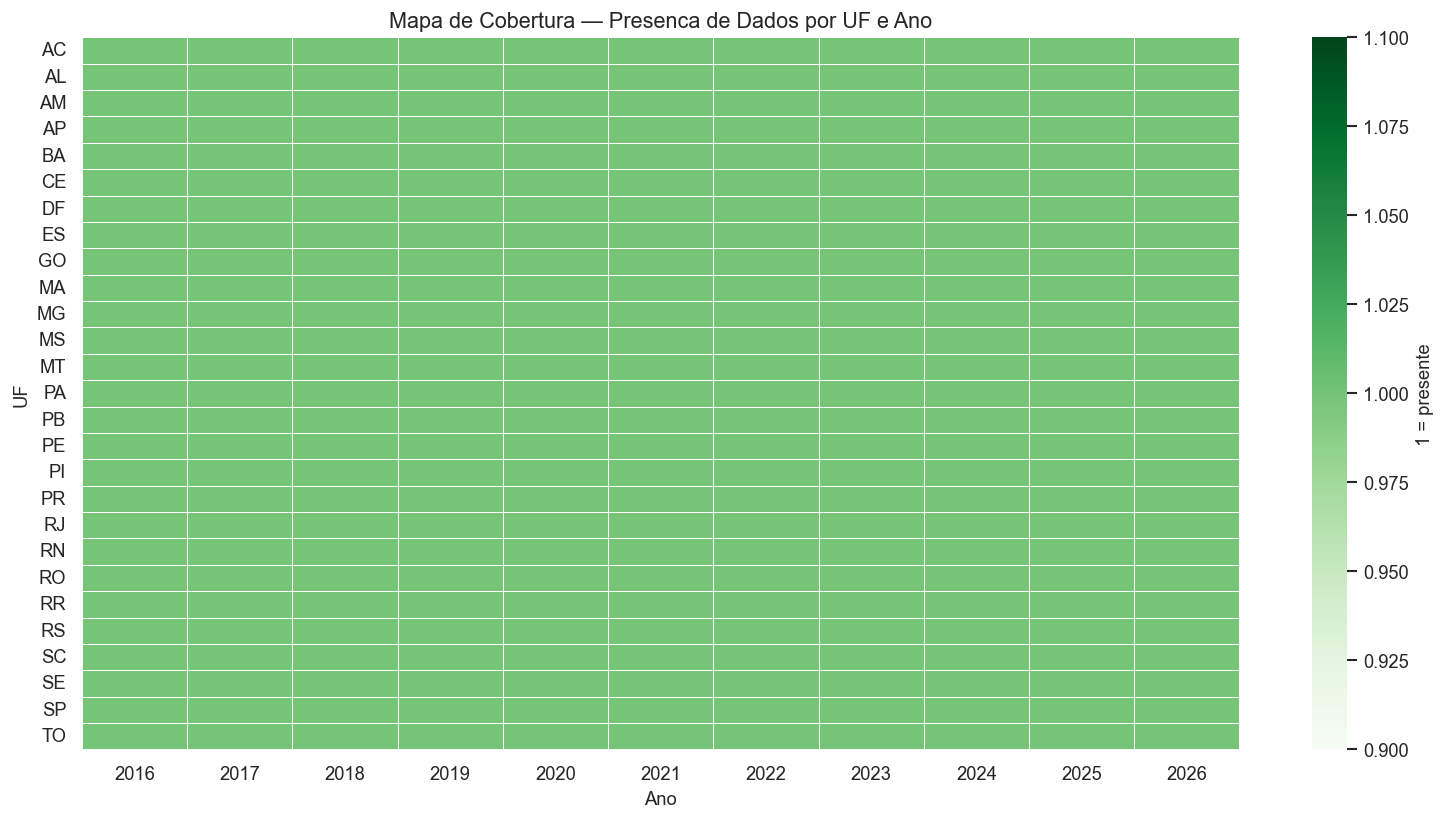

In [16]:
cobertura = df_raw.pivot_table(
    index='uf', columns='ano', values=VAR_PRINCIPAL, aggfunc='sum')
mascara = (~cobertura.isnull()).astype(int)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(mascara, annot=False, cmap='Greens', linewidths=0.4,
            cbar_kws={'label': '1 = presente'}, ax=ax)
ax.set_title('Mapa de Cobertura — Presenca de Dados por UF e Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('UF')
plt.tight_layout(); plt.show()

In [17]:
zeros = (
    df_raw[df_raw[VAR_PRINCIPAL] == 0]
    .groupby('ano')['uf']
    .apply(lambda x: sorted(x.tolist()))
)
print(f'UFs com {VAR_PRINCIPAL} = 0 por ano:')
for ano, ufs in zeros.items():
    print(f'  {ano}: {len(ufs)} UF(s) -> {ufs}')
print('\nNOTA: RJ = zero em todos os anos. Tratado como NaN (falha de notificacao).')

UFs com estupro_vulneravel = 0 por ano:
  2016: 10 UF(s) -> ['AC', 'AP', 'DF', 'ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2017: 10 UF(s) -> ['AC', 'AP', 'DF', 'ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2018: 8 UF(s) -> ['AP', 'ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2019: 7 UF(s) -> ['ES', 'MA', 'MS', 'PB', 'RJ', 'RO', 'TO']
  2020: 6 UF(s) -> ['ES', 'MA', 'MS', 'PB', 'RJ', 'RO']
  2021: 4 UF(s) -> ['ES', 'PB', 'RJ', 'RO']
  2022: 5 UF(s) -> ['ES', 'MS', 'PB', 'RJ', 'RO']
  2023: 4 UF(s) -> ['MS', 'PB', 'RJ', 'RO']
  2024: 4 UF(s) -> ['ES', 'MS', 'RJ', 'RO']
  2025: 1 UF(s) -> ['RJ']
  2026: 1 UF(s) -> ['RJ']

NOTA: RJ = zero em todos os anos. Tratado como NaN (falha de notificacao).


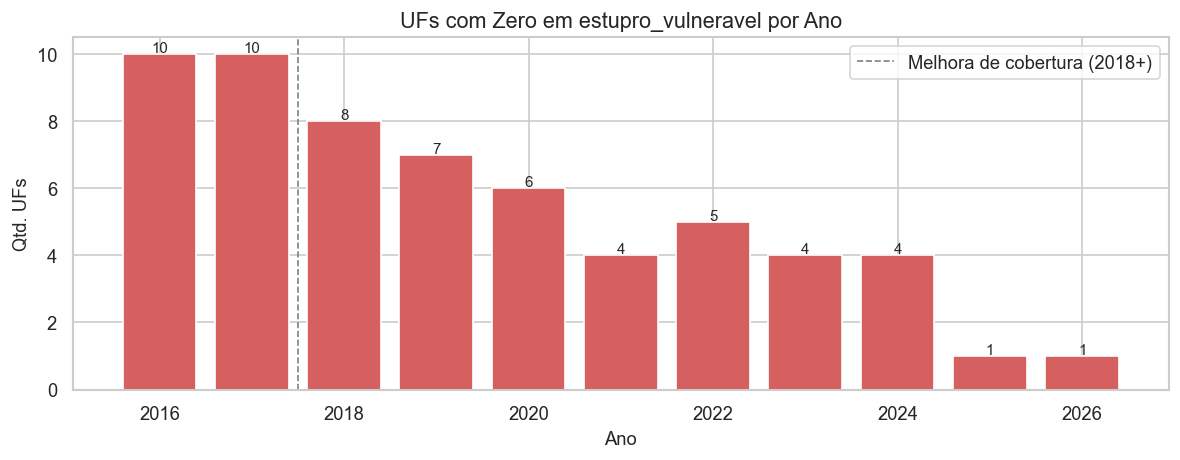

In [23]:
qtd_zeros = (
    df_raw[df_raw[VAR_PRINCIPAL] == 0]
    .groupby('ano')['uf'].count().reset_index(name='qtd')
)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(qtd_zeros['ano'], qtd_zeros['qtd'],
       color=sns.color_palette('muted')[3], edgecolor='white')
ax.axvline(x=2017.5, color='gray', linestyle='--', linewidth=1,
           label='Melhora de cobertura (2018+)')
ax.set_title(f'UFs com Zero em {VAR_PRINCIPAL} por Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('Qtd. UFs')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend()
for b in ax.patches:
    if b.get_height() > 0:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                str(int(b.get_height())), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

### Decisao: Janela de Analise

| Periodo | Problema | Decisao |
|---|---|---|
| 2016-2017 | 10 UFs com zeros sistematicos | Excluidos das analises de tendencia |
| 2026 | Ano parcial (Jan-Mar) | Excluido de comparacoes anuais |
| RJ (todos os anos) | Zero em todos os anos | Marcado como NaN |

**Janela principal: 2018-2025** (8 anos, melhor cobertura)

In [29]:
df = df_raw[
    (df_raw['ano'] >= ANO_INICIO) & (df_raw['ano'] <= ANO_FIM)
].copy()
df.loc[df['uf'] == 'RJ', VAR_PRINCIPAL] = np.nan

print(f'df_raw       : {df_raw.shape}')
print(f'df (filtrado): {df.shape}')
print(f'Periodo      : {df["ano"].min()} a {df["ano"].max()}')

df_raw       : (297, 4)
df (filtrado): (216, 4)
Periodo      : 2018 a 2025


---
## 5. Estatisticas Descritivas

In [30]:
df[['estupro', 'estupro_vulneravel']].describe().round(1)

,estupro,estupro_vulneravel
count,216.0,208.0
mean,1051.9,1944.7
std,1191.6,2376.1
min,83.0,0.0
25%,261.8,492.0
50%,695.5,1063.0
75%,1345.8,2761.2
max,5867.0,12452.0


In [32]:
totais = df.groupby('ano')[['estupro','estupro_vulneravel']].sum()
totais['prop_vulneravel'] = (
    totais['estupro_vulneravel'] /
    (totais['estupro'] + totais['estupro_vulneravel'])
).round(3)
print('Totais nacionais por ano (2018-2025):')
print(totais.to_string())
print(f'\nMedia anual - estupro_vulneravel: {totais["estupro_vulneravel"].mean():,.0f}')
print(f'Proporcao media estupro_vuln    : {totais["prop_vulneravel"].mean():.1%}')

Totais nacionais por ano (2018-2025):
      estupro  estupro_vulneravel  prop_vulneravel
ano                                               
2018    31968             40848.0            0.561
2019    32848             44702.0            0.576
2020    25228             41900.0            0.624
2021    27511             45093.0            0.621
2022    27391             53146.0            0.660
2023    28690             59779.0            0.676
2024    29440             59666.0            0.670
2025    24126             59366.0            0.711

Media anual - estupro_vulneravel: 50,562
Proporcao media estupro_vuln    : 63.7%


In [33]:
media_uf = (
    df.groupby('uf')[['estupro','estupro_vulneravel']]
    .mean().round(0)
    .sort_values(VAR_PRINCIPAL, ascending=False)
)
print('Media anual por UF (2018-2025):')
media_uf

Media anual por UF (2018-2025):


,estupro,estupro_vulneravel
uf,,
SP,3289.0,11023.0
PR,1572.0,5572.0
RS,1318.0,4006.0
MG,1398.0,3970.0
PA,830.0,3556.0
GO,808.0,3074.0
BA,1339.0,3029.0
SC,2027.0,2909.0
PE,821.0,1987.0


---
## 6. Analise de Distribuicoes

Distribuicoes com assimetria > 1 podem exigir transformacao log antes do Pearson.

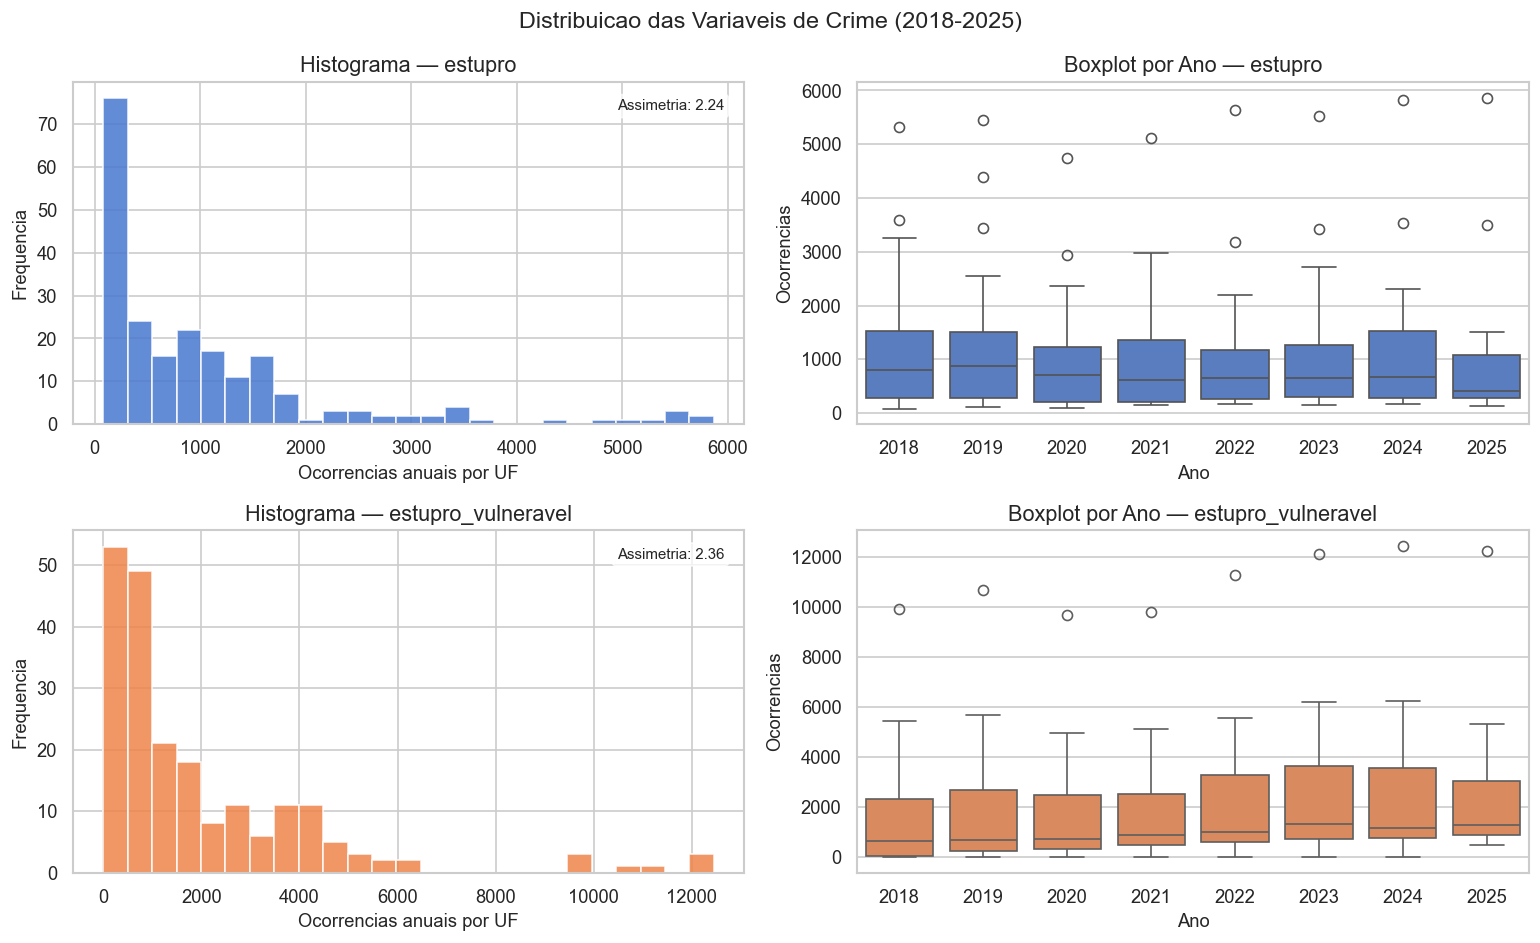


estupro: assimetria = 2.24  -> aplicar transformacao log
estupro_vulneravel: assimetria = 2.36  -> aplicar transformacao log


In [34]:
variaveis = ['estupro', 'estupro_vulneravel']
cores = sns.color_palette('muted', 2)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuicao das Variaveis de Crime (2018-2025)', fontsize=14)

for i, (var, cor) in enumerate(zip(variaveis, cores)):
    dados = df[var].dropna()
    sk    = dados.skew()

    axes[i,0].hist(dados, bins=25, color=cor, edgecolor='white', alpha=0.85)
    axes[i,0].set_title(f'Histograma — {var}')
    axes[i,0].set_xlabel('Ocorrencias anuais por UF')
    axes[i,0].set_ylabel('Frequencia')
    axes[i,0].text(0.97, 0.95, f'Assimetria: {sk:.2f}',
                   transform=axes[i,0].transAxes, ha='right', va='top',
                   fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    sns.boxplot(data=df[['ano',var]].dropna(), x='ano', y=var,
                color=cor, ax=axes[i,1])
    axes[i,1].set_title(f'Boxplot por Ano — {var}')
    axes[i,1].set_xlabel('Ano'); axes[i,1].set_ylabel('Ocorrencias')

plt.tight_layout(); plt.show()
print()
for var in variaveis:
    sk = df[var].dropna().skew()
    rec = '-> aplicar transformacao log' if abs(sk) > 1 else '-> distribuicao aceitavel'
    print(f'{var}: assimetria = {sk:.2f}  {rec}')

---
## 7. Analise Temporal

Evolucao nacional e variacao YoY (ano a ano).

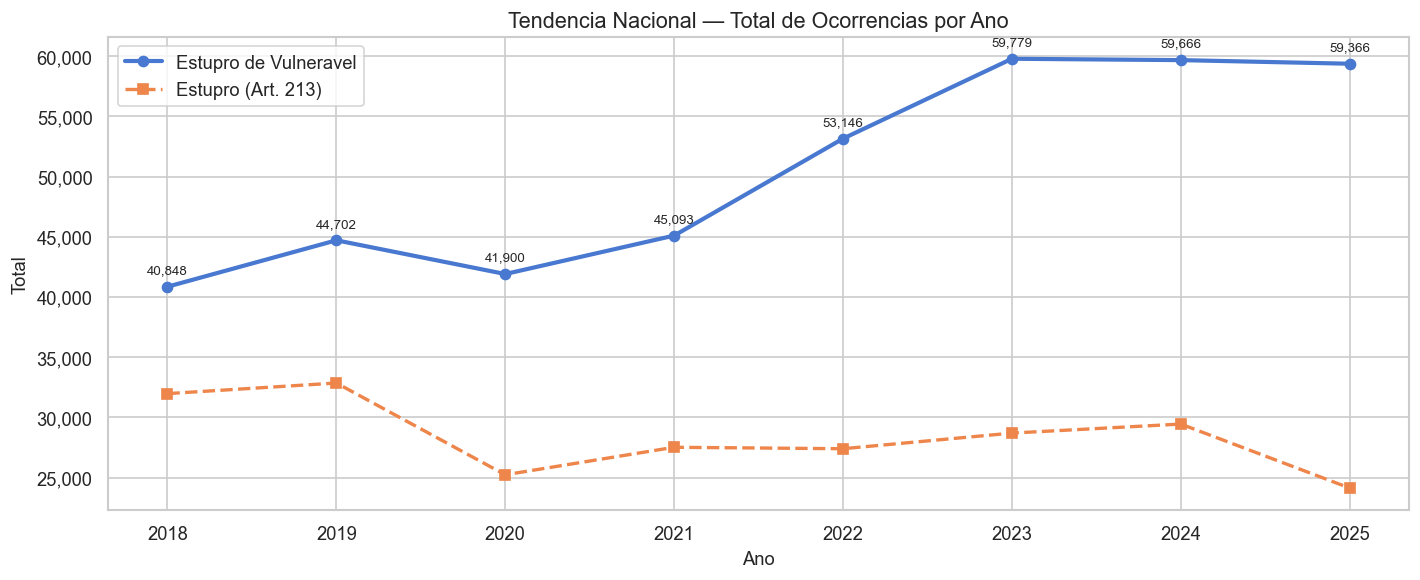

In [36]:
tendencia = df.groupby('ano')[['estupro','estupro_vulneravel']].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tendencia['ano'], tendencia['estupro_vulneravel'],
        marker='o', linewidth=2.5, label='Estupro de Vulneravel',
        color=sns.color_palette('muted')[0])
ax.plot(tendencia['ano'], tendencia['estupro'],
        marker='s', linewidth=2, linestyle='--', label='Estupro (Art. 213)',
        color=sns.color_palette('muted')[1])
ax.set_title('Tendencia Nacional — Total de Ocorrencias por Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('Total')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_xticks(tendencia['ano']); ax.legend()
for _, row in tendencia.iterrows():
    ax.annotate(f"{row['estupro_vulneravel']:,.0f}",
                (row['ano'], row['estupro_vulneravel']),
                textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

In [37]:
tendencia['yoy_vuln']    = tendencia['estupro_vulneravel'].pct_change().mul(100).round(1)
tendencia['yoy_estupro'] = tendencia['estupro'].pct_change().mul(100).round(1)
print('Variacao percentual anual (YoY):')
print(tendencia[['ano','estupro_vulneravel','yoy_vuln','estupro','yoy_estupro']]
      .to_string(index=False))
cresc = (tendencia.iloc[-1]['estupro_vulneravel'] /
         tendencia.iloc[0]['estupro_vulneravel'] - 1) * 100
print(f'\nCrescimento total 2018->2025: {cresc:.1f}%')

Variacao percentual anual (YoY):
 ano  estupro_vulneravel  yoy_vuln  estupro  yoy_estupro
2018             40848.0       NaN    31968          NaN
2019             44702.0       9.4    32848          2.8
2020             41900.0      -6.3    25228        -23.2
2021             45093.0       7.6    27511          9.0
2022             53146.0      17.9    27391         -0.4
2023             59779.0      12.5    28690          4.7
2024             59666.0      -0.2    29440          2.6
2025             59366.0      -0.5    24126        -18.1

Crescimento total 2018->2025: 45.3%


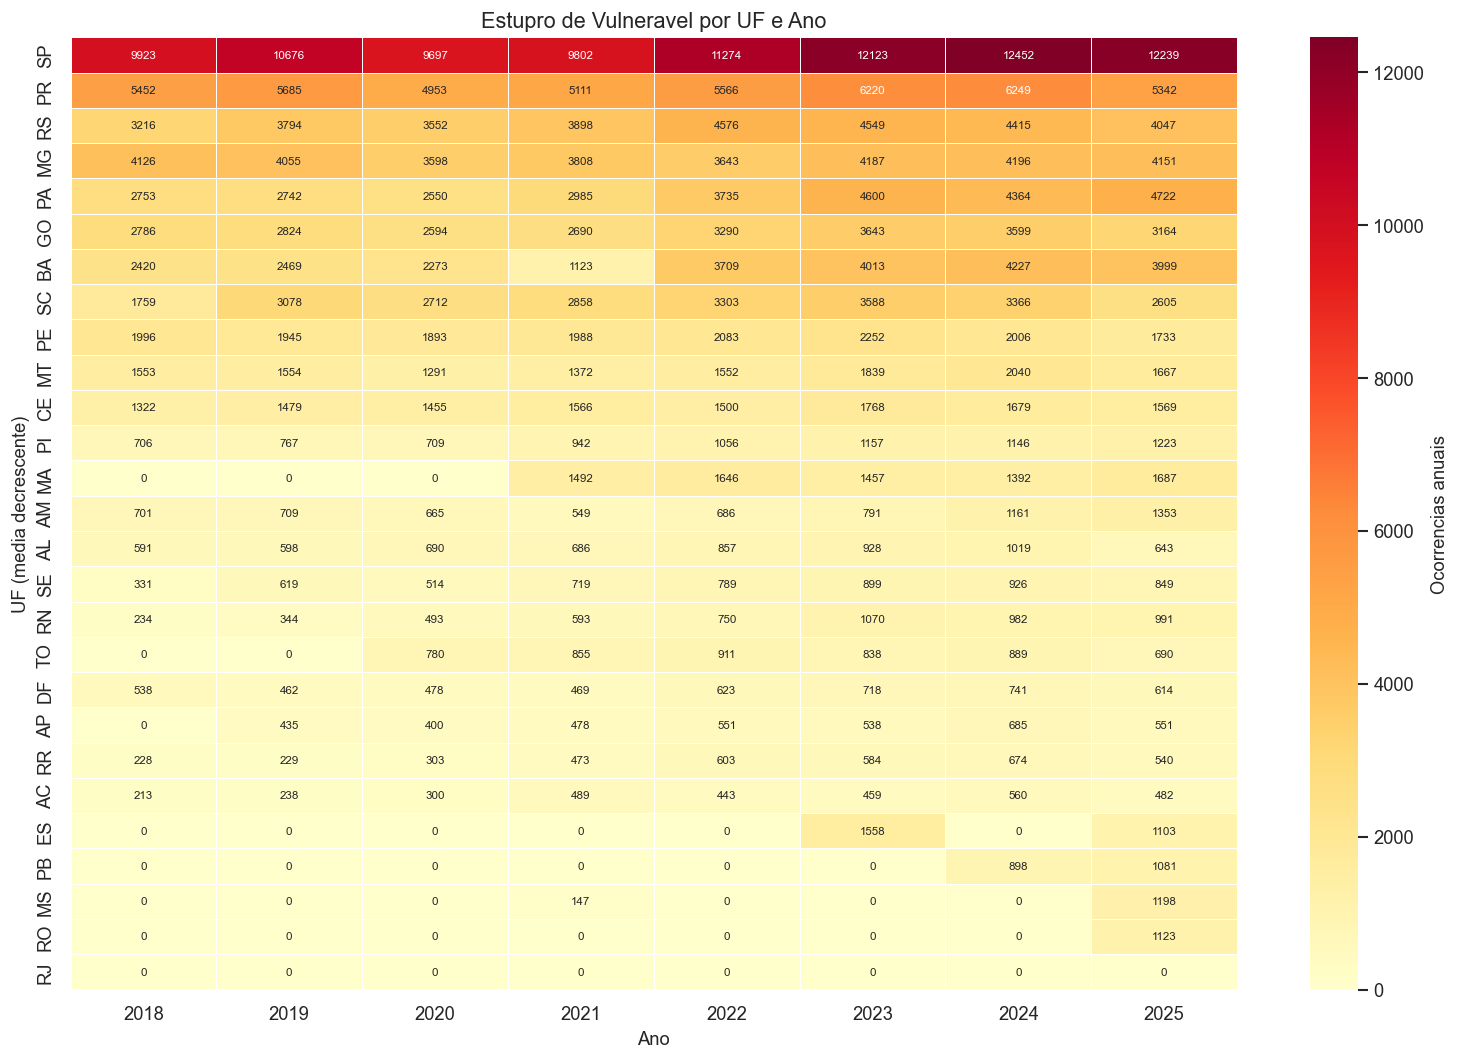

In [38]:
pivot = df.pivot_table(index='uf', columns='ano',
                       values=VAR_PRINCIPAL, aggfunc='sum')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3,
            annot=True, fmt='.0f', annot_kws={'size': 7},
            cbar_kws={'label': 'Ocorrencias anuais'}, ax=ax)
ax.set_title('Estupro de Vulneravel por UF e Ano')
ax.set_xlabel('Ano'); ax.set_ylabel('UF (media decrescente)')
plt.tight_layout(); plt.show()

---
## 8. Analise Geografica

Ranking dos estados por total acumulado no periodo 2018-2025.

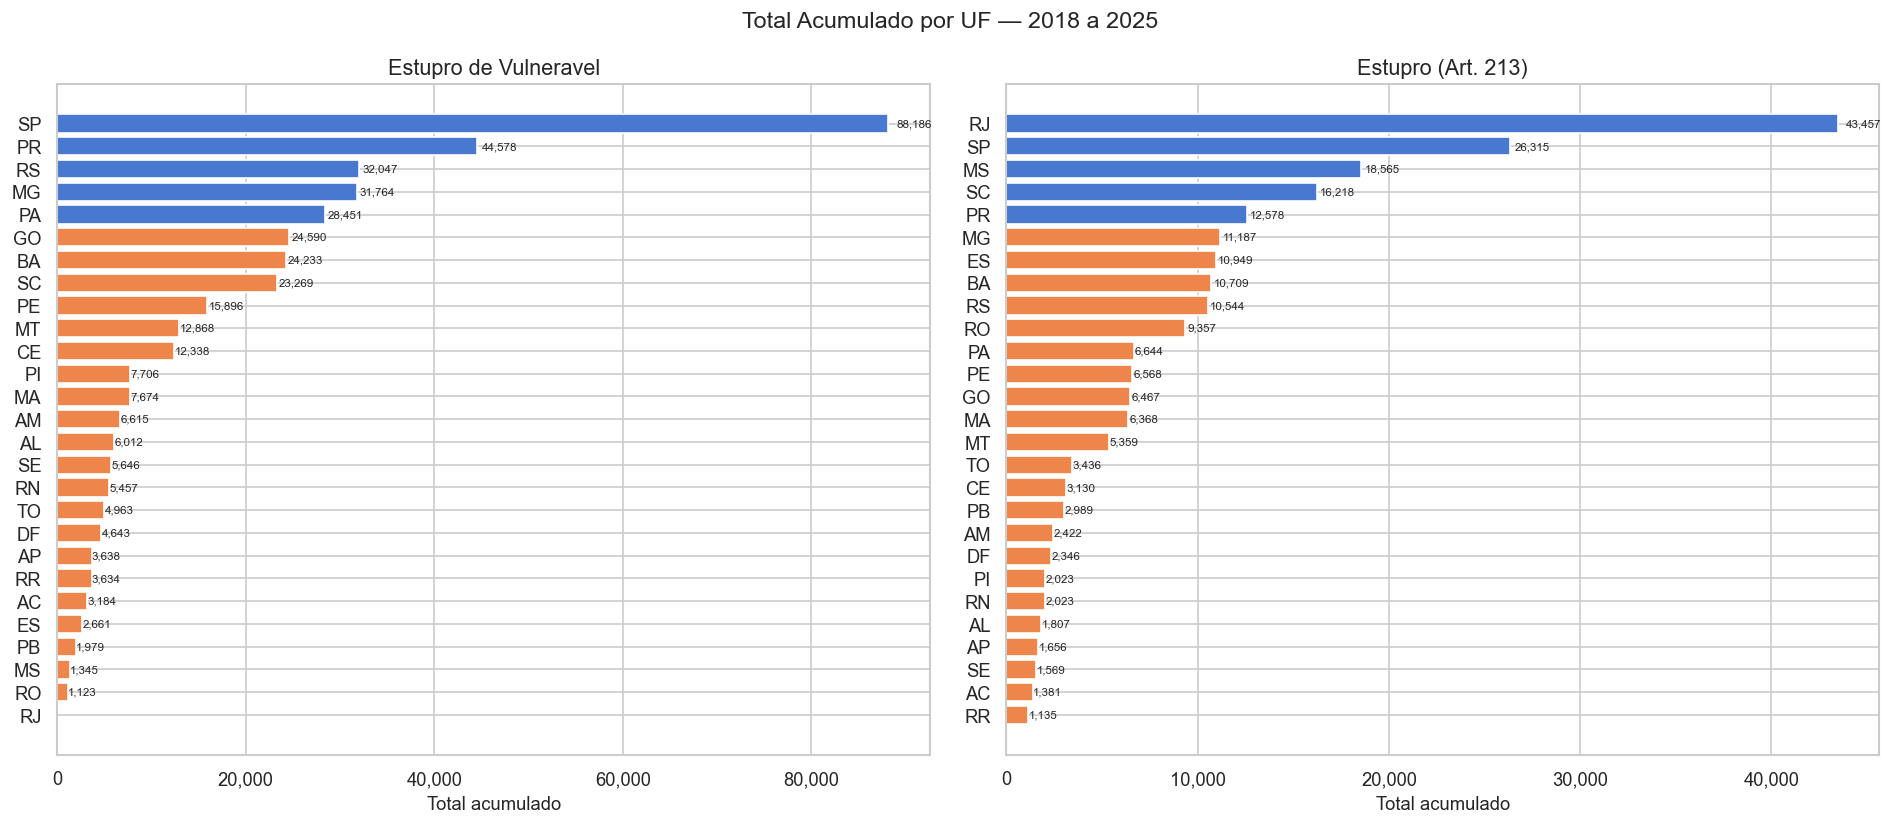

In [39]:
acum = (
    df.groupby('uf')[['estupro','estupro_vulneravel']]
    .sum().sort_values(VAR_PRINCIPAL, ascending=False).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Total Acumulado por UF — 2018 a 2025', fontsize=14)

for ax, var, titulo in zip(
    axes,
    ['estupro_vulneravel', 'estupro'],
    ['Estupro de Vulneravel', 'Estupro (Art. 213)']):

    dados = acum.sort_values(var, ascending=True)
    n     = len(dados)
    cores = [sns.color_palette('muted')[1]] * n
    for j in range(max(0, n-5), n): cores[j] = sns.color_palette('muted')[0]

    ax.barh(dados['uf'], dados[var], color=cores, edgecolor='white')
    ax.set_title(titulo); ax.set_xlabel('Total acumulado')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    for j, (_, row) in enumerate(dados.iterrows()):
        if row[var] > 0:
            ax.text(row[var]*1.01, j, f"{row[var]:,.0f}", va='center', fontsize=7)

plt.tight_layout(); plt.show()

In [40]:
sem_rj = acum[acum['uf'] != 'RJ']
print('=== TOP 5 — estupro_vulneravel (2018-2025) ===')
print(sem_rj.nlargest(5, VAR_PRINCIPAL)[['uf', VAR_PRINCIPAL]].to_string(index=False))
print('\n=== BOTTOM 5 ===')
print(sem_rj.nsmallest(5, VAR_PRINCIPAL)[['uf', VAR_PRINCIPAL]].to_string(index=False))
print('\nNOTA: volume absoluto e afetado por populacao.')
print('Taxa por 100k sera calculada apos incorporar dados do IBGE.')

=== TOP 5 — estupro_vulneravel (2018-2025) ===
uf  estupro_vulneravel
SP             88186.0
PR             44578.0
RS             32047.0
MG             31764.0
PA             28451.0

=== BOTTOM 5 ===
uf  estupro_vulneravel
RO              1123.0
MS              1345.0
PB              1979.0
ES              2661.0
AC              3184.0

NOTA: volume absoluto e afetado por populacao.
Taxa por 100k sera calculada apos incorporar dados do IBGE.


---
## 9. Analise de Correlacao

### 9a. Correlacao entre as variaveis de crime

Pearson e Spearman reportados — dados assimetricos requerem ambos.

In [ ]:
dados_corr = df[['estupro', 'estupro_vulneravel']].dropna()
r_p, p_p = stats.pearsonr(dados_corr['estupro'], dados_corr['estupro_vulneravel'])
r_s, p_s = stats.spearmanr(dados_corr['estupro'], dados_corr['estupro_vulneravel'])

print('Correlacao: estupro vs estupro_vulneravel')
print(f'  Pearson  r = {r_p:.4f}  (p = {p_p:.4e})')
print(f'  Spearman r = {r_s:.4f}  (p = {p_s:.4e})')

#pearson comparação estrupro x estupro_vulneravel, para verificar se ambas crescem juntas (quanto mais crescer juntas, maior o r)
#spearman comparação estrupro x estupro_vulneravel, para verificar se ambas tem os rankings parecidos (ex: se uma UF tem mais estrupos, tem mais estupros de vulneravel?)
#quanto menor o p-value, menor a chance do resultado ter ocorrido por acaso

Correlacao: estupro vs estupro_vulneravel
  Pearson  r = 0.6247  (p = 6.5621e-24)
  Spearman r = 0.4261  (p = 1.3989e-10)


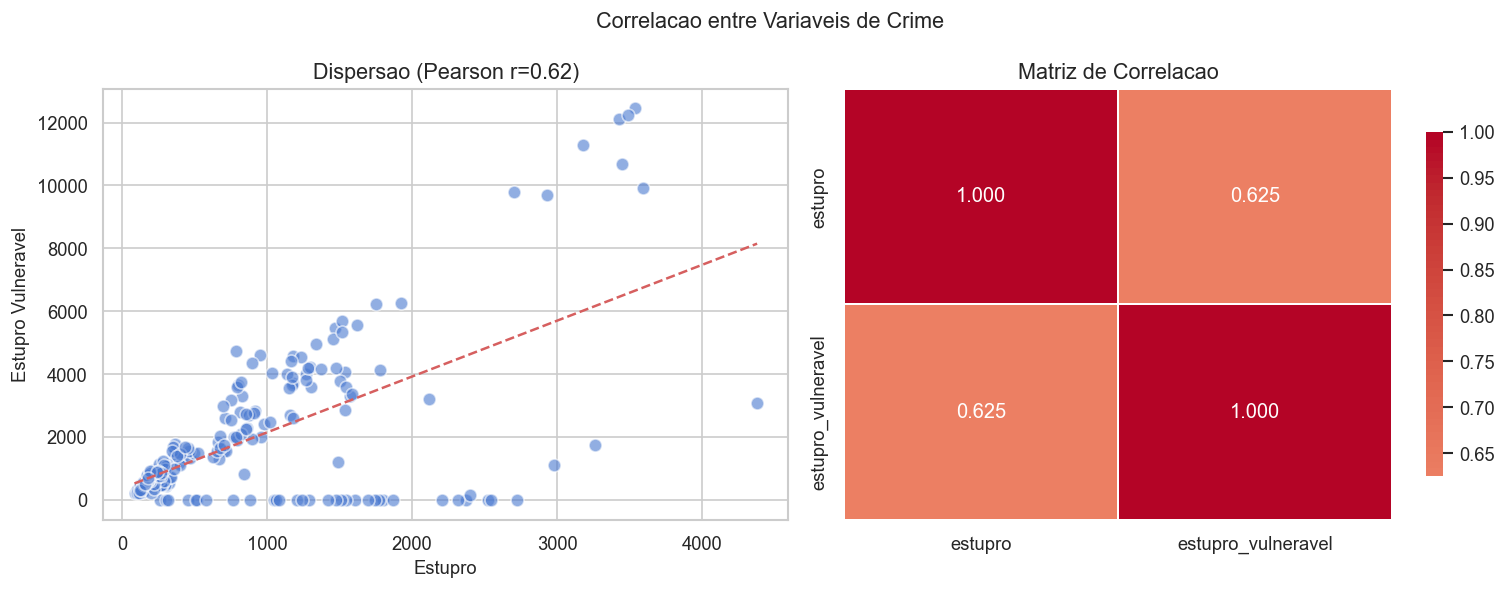

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Correlacao entre Variaveis de Crime', fontsize=13)

axes[0].scatter(dados_corr['estupro'], dados_corr['estupro_vulneravel'],
                alpha=0.6, color=sns.color_palette('muted')[0],
                edgecolors='white', s=60)
z  = np.polyfit(dados_corr['estupro'], dados_corr['estupro_vulneravel'], 1)
xl = np.linspace(dados_corr['estupro'].min(), dados_corr['estupro'].max(), 100)
axes[0].plot(xl, np.poly1d(z)(xl), 'r--', linewidth=1.5)
axes[0].set_title(f'Dispersao (Pearson r={r_p:.2f})')
axes[0].set_xlabel('Estupro'); axes[0].set_ylabel('Estupro Vulneravel')

sns.heatmap(dados_corr.corr(), annot=True, fmt='.3f',
            cmap='coolwarm', center=0, linewidths=1,
            cbar_kws={'shrink': 0.8}, ax=axes[1])
axes[1].set_title('Matriz de Correlacao')
plt.tight_layout(); plt.show()

#quanto mais proximo de 1 o 0.625 ou -1 for, mais um tende a aumentar junto ao outro.

### 9b. Correlacao com Variaveis Socioeconomicas

> **Aguardando dados do IBGE.** Sera executado apos a fusao com `ibge_socioeconomico.csv`.

Variaveis esperadas: `renda_per_capita`, `indice_gini`, `taxa_desemprego`,
`pct_pobreza`, `densidade_demografica`, `populacao`.

In [43]:
IBGE_FILE = DATA_DIR / 'ibge_socioeconomico.csv'
VARS_IBGE = ['renda_per_capita', 'indice_gini', 'taxa_desemprego',
             'pct_pobreza', 'densidade_demografica']

if IBGE_FILE.exists():
    df_ibge   = pd.read_csv(IBGE_FILE)
    df_merged = df.merge(df_ibge, on=['uf', 'ano'], how='inner')

    if 'populacao' in df_merged.columns:
        df_merged['taxa_por_100k'] = (
            df_merged[VAR_PRINCIPAL] / df_merged['populacao'] * 100_000
        ).round(2)

    print('Correlacoes — taxa_por_100k vs indicadores socioeconomicos:')
    for var in VARS_IBGE:
        if var in df_merged.columns:
            d = df_merged[['taxa_por_100k', var]].dropna()
            rp, pp = stats.pearsonr(d['taxa_por_100k'], d[var])
            rs, ps = stats.spearmanr(d['taxa_por_100k'], d[var])
            sig = '*' if pp < 0.05 else 'n.s.'
            print(f'  {var:<25} Pearson={rp:+.3f}({sig})  Spearman={rs:+.3f}')

    cols_p = ['taxa_por_100k'] + [v for v in VARS_IBGE if v in df_merged.columns]
    plt.figure(figsize=(9, 7))
    sns.heatmap(df_merged[cols_p].corr(), annot=True, fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.5)
    plt.title('Correlacao: Crimes vs Indicadores Socioeconomicos')
    plt.tight_layout(); plt.show()
else:
    print(f'[AGUARDANDO] {IBGE_FILE} nao encontrado.')
    print('Execute o pipeline do IBGE e reexecute esta celula.')

[AGUARDANDO] ..\data\processed\ibge_socioeconomico.csv nao encontrado.
Execute o pipeline do IBGE e reexecute esta celula.


---
## 10. Preparacao para Clusterizacao (K-Means)

Matriz de features preliminar baseada apenas em crimes.
Sera expandida com variaveis do IBGE antes da clusterizacao definitiva.

In [44]:
feat = (
    df[df['uf'] != 'RJ']
    .groupby('uf')[['estupro', 'estupro_vulneravel']]
    .mean().dropna()
)
scaler     = StandardScaler()
feat_scaled = pd.DataFrame(
    scaler.fit_transform(feat),
    index=feat.index, columns=feat.columns
)
print(f'Estados na matriz: {len(feat)}')
feat_scaled.head()

Estados na matriz: 26


,estupro,estupro_vulneravel
uf,,
AC,-0.926927,-0.665924
AL,-0.857483,-0.513728
AM,-0.757228,-0.481276
AP,-0.882098,-0.641491
BA,0.593685,0.466885


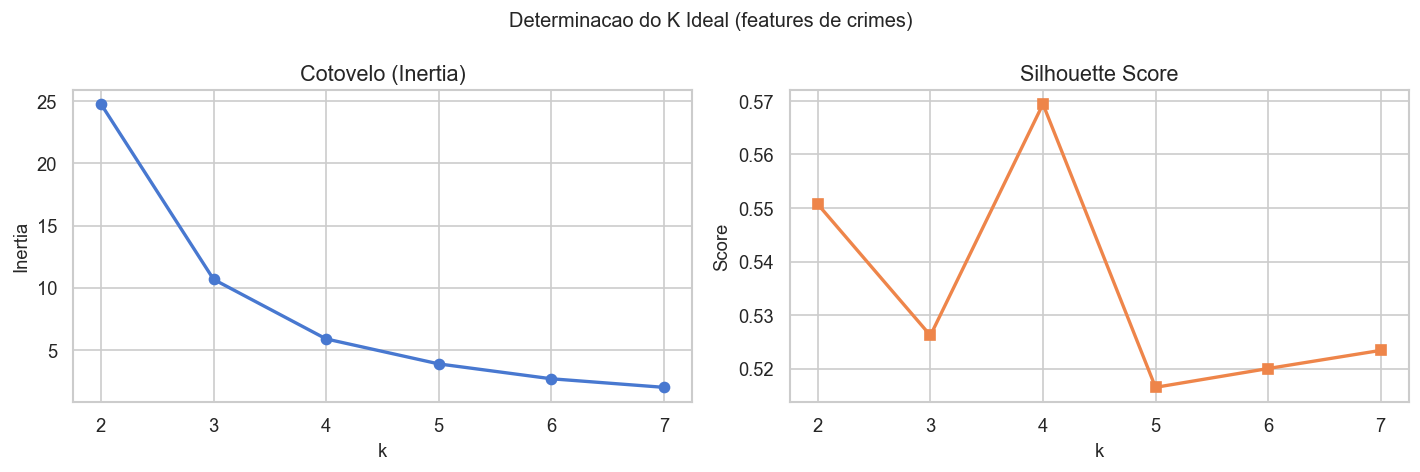

K com maior silhouette: 4  (score=0.569)


In [ ]:
inertias, silhouettes = [], []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(feat_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(feat_scaled, lb))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Determinacao do K Ideal (features de crimes)', fontsize=12)

axes[0].plot(list(k_range), inertias, marker='o',
             color=sns.color_palette('muted')[0], linewidth=2)
axes[0].set_title('Cotovelo (Inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='s',
             color=sns.color_palette('muted')[1], linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')

plt.tight_layout(); plt.show()
k_ideal = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'K com maior silhouette: {k_ideal}  (score={max(silhouettes):.3f})')

#quanto menor o cotevelo melhor, mas pode ser subjetivo. O silhouette é mais objetivo, quanto mais proximo de 1 melhor. Aqui o ideal seria k=2, mas k=3 tambem tem um score alto e pode ser interessante para diferenciar os grupos.
#cada K eh um grupo parecido k = 2, 2 grupos parecidos k = 3, 3 grupos parecidos... e assim por diante. O ideal é escolher um K que seja baixo (para facilitar interpretacao) mas que tenha um silhouette alto (para garantir que os grupos sejam bem formados).

In [ ]:
km_final = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
feat['cluster'] = km_final.fit_predict(feat_scaled)

print(f'Distribuicao dos estados por cluster (k={k_ideal}):')
for c in sorted(feat['cluster'].unique()):
    estados = feat[feat['cluster'] == c].index.tolist()
    media   = feat.loc[estados, VAR_PRINCIPAL].mean()
    print(f'  Cluster {c+1} ({len(estados)} estados): {sorted(estados)}')
    print(f'           Media estupro_vulneravel: {media:,.0f}/ano')
print('\nNOTA: clusters preliminares. Refazer apos fusao com IBGE.')

#grupos K=4 (Baixo, 852/ano, Extremo 11023/ano, Muito Baixo 214/ano e Alto 3713/ano).

Distribuicao dos estados por cluster (k=4):
  Cluster 1 (15 estados): ['AC', 'AL', 'AM', 'AP', 'CE', 'DF', 'MA', 'MT', 'PB', 'PE', 'PI', 'RN', 'RR', 'SE', 'TO']
           Media estupro_vulneravel: 852/ano
  Cluster 2 (1 estados): ['SP']
           Media estupro_vulneravel: 11,023/ano
  Cluster 3 (3 estados): ['ES', 'MS', 'RO']
           Media estupro_vulneravel: 214/ano
  Cluster 4 (7 estados): ['BA', 'GO', 'MG', 'PA', 'PR', 'RS', 'SC']
           Media estupro_vulneravel: 3,731/ano

NOTA: clusters preliminares. Refazer apos fusao com IBGE.


---
## 11. Proximos Passos

### Resumo desta analise

| Dimensao | Resultado |
|---|---|
| Qualidade | RJ ausente todos os anos; 10 UFs zeros em 2016-2017 |
| Janela recomendada | 2018-2025 (cobertura consistente) |
| Tendencia nacional | Crescimento continuo de `estupro_vulneravel` |
| Estados criticos | SP, MG, BA — maior volume absoluto |
| Distribuicao | Alta assimetria — considerar transformacao log |
| Clustering | Estrutura preliminar; requer features socioeconomicas |

### Pendencias prioritarias

1. **IBGE Estimativas Populacionais** — calcular `taxa_por_100k`
2. **IBGE PNAD Continua** — executar correlacao crime x renda/Gini (Secao 9b)
3. **Fontes alternativas** — `sequestro` e `exploracao_infantil` nao estao no SINESP
4. **Tratar RJ** — investigar fonte alternativa para os anos zerados

---

> **Aviso metodologico:** Esta analise e descritiva e correlacional.
> Correlacao nao implica causalidade.